<a href="https://colab.research.google.com/github/JorgePeje/test-python-utec/blob/main/LineatiempoGEconparadas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------
# CARGAR ARCHIVO
# -------------------------

from google.colab import files
uploaded = files.upload()

Saving truck_events.xlsx to truck_events (1).xlsx


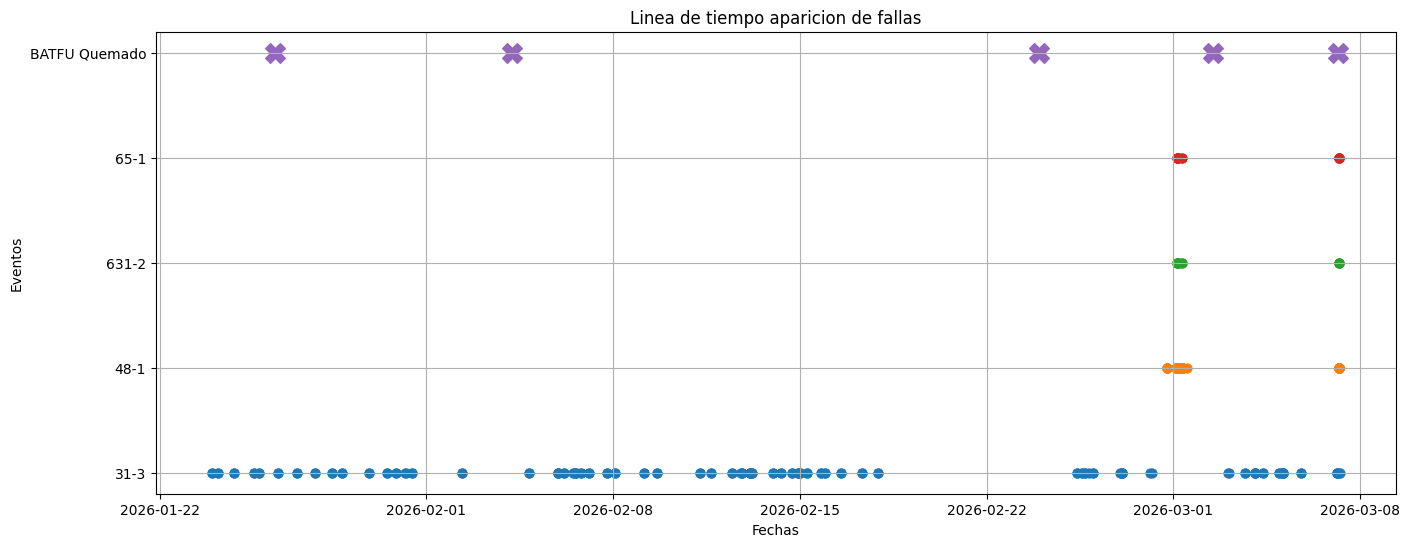

In [5]:



df = pd.read_excel("truck_events.xlsx")

# convertir tiempo
df["Time"] = pd.to_datetime(df["Time"])

# crear etiqueta evento
df["event_label"] = df["Event #"].astype(str) + "-" + df["Sub ID"].astype(str)

# eventos que queremos analizar
events_of_interest = ["31-3","48-1","65-1","631-2"]

df = df[df["event_label"].isin(events_of_interest)]

# -------------------------
# FALLAS DEL FUSIBLE BATFU
# -------------------------

fuse_times = [
"2026-01-26 07:37:50",
"2026-02-04 05:13:36",
"2026-02-23 23:11:55",
"2026-03-02 11:23:38",
"2026-03-07 03:39:02"
]

fuse_df = pd.DataFrame({"Time":pd.to_datetime(fuse_times)})
fuse_df["event_label"] = "BATFU Quemado"

# -------------------------
# GRAFICO TIMELINE
# -------------------------

plt.figure(figsize=(16,6))

for label, group in df.groupby("event_label"):
    plt.scatter(group["Time"], [label]*len(group), s=40)

# fusible
plt.scatter(
    fuse_df["Time"],
    fuse_df["event_label"],
    marker="X",
    s=200
)

plt.title("Linea de tiempo aparicion de fallas")
plt.xlabel("Fechas")
plt.ylabel("Eventos")

plt.grid(True)
plt.show()